# Regional Downscaling over Europe

Diffusion downscaling from a global forecast to km-scale European reanalysis grids.

This example demonstrates composing a global prognostic model (SFNO) with a
regional diffusion downscaler (``CorrDiffCosmoEra5``). SFNO's 73-variable output
is a superset of the downscaler's 47-channel ERA5 input, so the hand-off is a
variable subset plus a bilinear regrid onto the regional input grid. The package
bundles both a generative *diffusion* downscaler and a deterministic *regression*
(mean) model, selected via ``mode`` on ``load_model``.

In this example you will learn:

- How to run the COSMO-REA6 diffusion downscaler over Europe, and on a sub-domain
- How to draw a diffusion ensemble and contrast it with the deterministic regression mean
- How to roll out a downscaled forecast with ``DiagnosticWrapper``
- How to derive hub-height wind (100 m) for wind-energy use
- How to switch to the 2.2 km COSMO-REA2 resolution

## Configuration
Set up all tuneable parameters for the example: forecast init time, lead time,
diffusion sampler settings, ensemble size, device, and the geographic domain for
sub-region downscaling.

In [1]:
import os
from collections import OrderedDict
from datetime import datetime, timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import torch
from dotenv import load_dotenv
from scipy.interpolate import RegularGridInterpolator

load_dotenv()  # pick up $COSMO_REA_PACKAGE from a .env file if present

# The downscaling package (rea6/ + rea2/ subfolders) is hosted on Hugging Face and
# fetched by load_default_package(). Set $COSMO_REA_PACKAGE to a locally built
# package to use that instead. (Resolved after the imports below.)
local_package = os.environ.get("COSMO_REA_PACKAGE")

init_time = datetime(2021, 7, 13, 0)  # forecast initialization
lead_hours = 24  # forecast lead time to downscale
sampler_steps = 12  # diffusion denoising steps (more = sharper, slower; diffusion only)
amp = True  # reduced-precision (bf16) autocast: faster, lower memory on recent GPUs
ensemble_size = 9  # diffusion ensemble members for the Germany sub-domain
device = "cuda:0"
germany = dict(lat_min=47.0, lat_max=55.5, lon_min=5.0, lon_max=16.0)
projection = (
    ccrs.PlateCarree()
)  # COSMO-REA lat/lon are geographic; plot with coastlines

os.makedirs("outputs", exist_ok=True)


def geo_axes(ax):
    """Add coastlines and gridlines to a cartopy GeoAxes."""
    ax.coastlines(resolution="50m", linewidth=0.6, color="0.3")
    ax.gridlines(linewidth=0.3, color="0.5", alpha=0.5)


/__w/earth2studio/earth2studio/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Load the global forecaster and the regional downscaler
Instantiate SFNO (the global prognostic model) and CorrDiffCosmoEra5 (the
regional downscaler). Both diffusion and regression checkpoints are loaded from
the same package; ``mode`` selects which one.

In [2]:
from earth2studio.data import ARCO, fetch_data
from earth2studio.models.auto import Package
from earth2studio.models.dx import CorrDiffCosmoEra5
from earth2studio.models.px import SFNO

# Resolve the downscaling package: the hosted default, or a local build if
# $COSMO_REA_PACKAGE was set above.
if local_package:
    package = Package(local_package)
else:
    package = CorrDiffCosmoEra5.load_default_package()

sfno = SFNO.load_model(SFNO.load_default_package()).to(device)
# Both models live in the same package; `mode` selects which checkpoint to load:
# the diffusion model is generative, the mean model is the deterministic regression.
dx = CorrDiffCosmoEra5.load_model(
    package, device=device, mode="diffusion", resolution="rea6"
)
dx.amp = amp
dx.number_of_steps = sampler_steps
dx_mean = CorrDiffCosmoEra5.load_model(
    package, device=device, mode="mean", resolution="rea6"
)
dx_mean.amp = amp


CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
2026-08-14 04:05:22.275 | INFO     | earth2studio.models.dx.corrdiff_cosmo_era5:load_model:1856 - Loaded CorrDiffCosmoEra5 resolution=rea6 mode=diffusion (45 output channels)
2026-08-14 04:05:30.152 | INFO     | earth2studio.models.dx.corrdiff_cosmo_era5:load_model:1856 - Loaded CorrDiffCosmoEra5 resolution=rea6 mode=mean (45 output channels)


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.13.0+cu130)
    Python  3.10.19 (you have 3.13.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Initial condition and global forecast
Fetch an ERA5 analysis (ARCO) initial condition and step SFNO forward to the
requested lead time. SFNO is 6-hourly, so 24 h is four steps.

In [3]:
sic = sfno.input_coords()
x, coords = fetch_data(
    ARCO(),
    time=np.array([np.datetime64(init_time)]),
    variable=sic["variable"],
    lead_time=sic["lead_time"],
    device=device,
)
dt_hours = int(sfno.output_coords(sic)["lead_time"][0] / np.timedelta64(1, "h"))
model = sfno.create_iterator(x, coords)
# The iterator yields the t=0 analysis first (before any forward step), so the four
# 6-hourly steps to 24 h take lead_hours // dt_hours + 1 = 5 calls (the first call
# consumes the initial condition).
for _ in range(lead_hours // dt_hours + 1):
    x_fc, coords_fc = next(model)  # global forecast state at the current step


Fetching ARCO data: 100%|██████████| 13/13 [00:03<00:00,  4.18it/s]


## Hand the forecast state to the downscaler
Select the 47 ERA5 channels the downscaler needs and bilinearly regrid the
global SFNO field onto the downscaler's regional input grid (handling the seam
where longitude wraps at 0/360 deg). The forecast validity time is passed as the
``time`` coord; it drives the model's day/night (solar-zenith) input channel. One
shared regrid helper backs both the manual calls and the ``DiagnosticWrapper``
hook below.

In [4]:
def regrid_to_input(x_src, src_coords, dvars, dlat, dlon):
    """Subset to the downscaler's ERA5 variables and bilinearly regrid a global
    regular lat/lon field onto its regional grid. Returns [n_var, n_lat, n_lon]."""
    svars = list(src_coords["variable"])
    slat = np.asarray(src_coords["lat"]).astype(float)
    slon = np.asarray(src_coords["lon"]).astype(float)
    field = x_src.reshape(-1, len(svars), len(slat), len(slon))[0].float().cpu().numpy()
    field = field[[svars.index(v) for v in dvars]]  # select the 47 channels
    if slat[0] > slat[-1]:  # ensure ascending latitude
        slat, field = slat[::-1], field[:, ::-1, :]
    field_w = np.concatenate([field, field[:, :, 0:1]], axis=-1)  # lon wrap column
    slon_w = np.concatenate([slon, [slon[0] + 360.0]])
    lon2d, lat2d = np.meshgrid(dlon % 360.0, dlat)
    pts = np.stack([lat2d.ravel(), lon2d.ravel()], axis=-1)
    out = np.empty((len(dvars), len(dlat), len(dlon)), np.float32)
    for c in range(len(dvars)):
        out[c] = RegularGridInterpolator(
            (slat, slon_w), field_w[c], bounds_error=False, fill_value=None
        )(pts).reshape(len(dlat), len(dlon))
    return out


def sfno_to_downscaler(x_fc, coords_fc, dx, valid_time):
    """Map a global SFNO step output to the downscaler's regional input + coords."""
    ic = dx.input_coords()
    dvars = list(ic["variable"])
    dlat, dlon = np.asarray(ic["lat"]), np.asarray(ic["lon"])
    out = regrid_to_input(x_fc, coords_fc, dvars, dlat, dlon)
    coords_dx = OrderedDict(
        batch=np.array([0]),
        time=np.array([np.datetime64(valid_time)]),
        variable=np.array(dvars),
        lat=dlat,
        lon=dlon,
    )
    return torch.from_numpy(out)[None, None].to(x_fc.device), coords_dx


valid_time = init_time + timedelta(hours=lead_hours)
x_dx, coords_dx = sfno_to_downscaler(x_fc, coords_fc, dx, valid_time)
out, out_coords = dx(x_dx, coords_dx)


## Plot the downscaled fields
Visualise four representative channels from the full-domain COSMO-REA6 output:
2 m temperature, total precipitation, 10 m zonal wind, and total cloud cover.

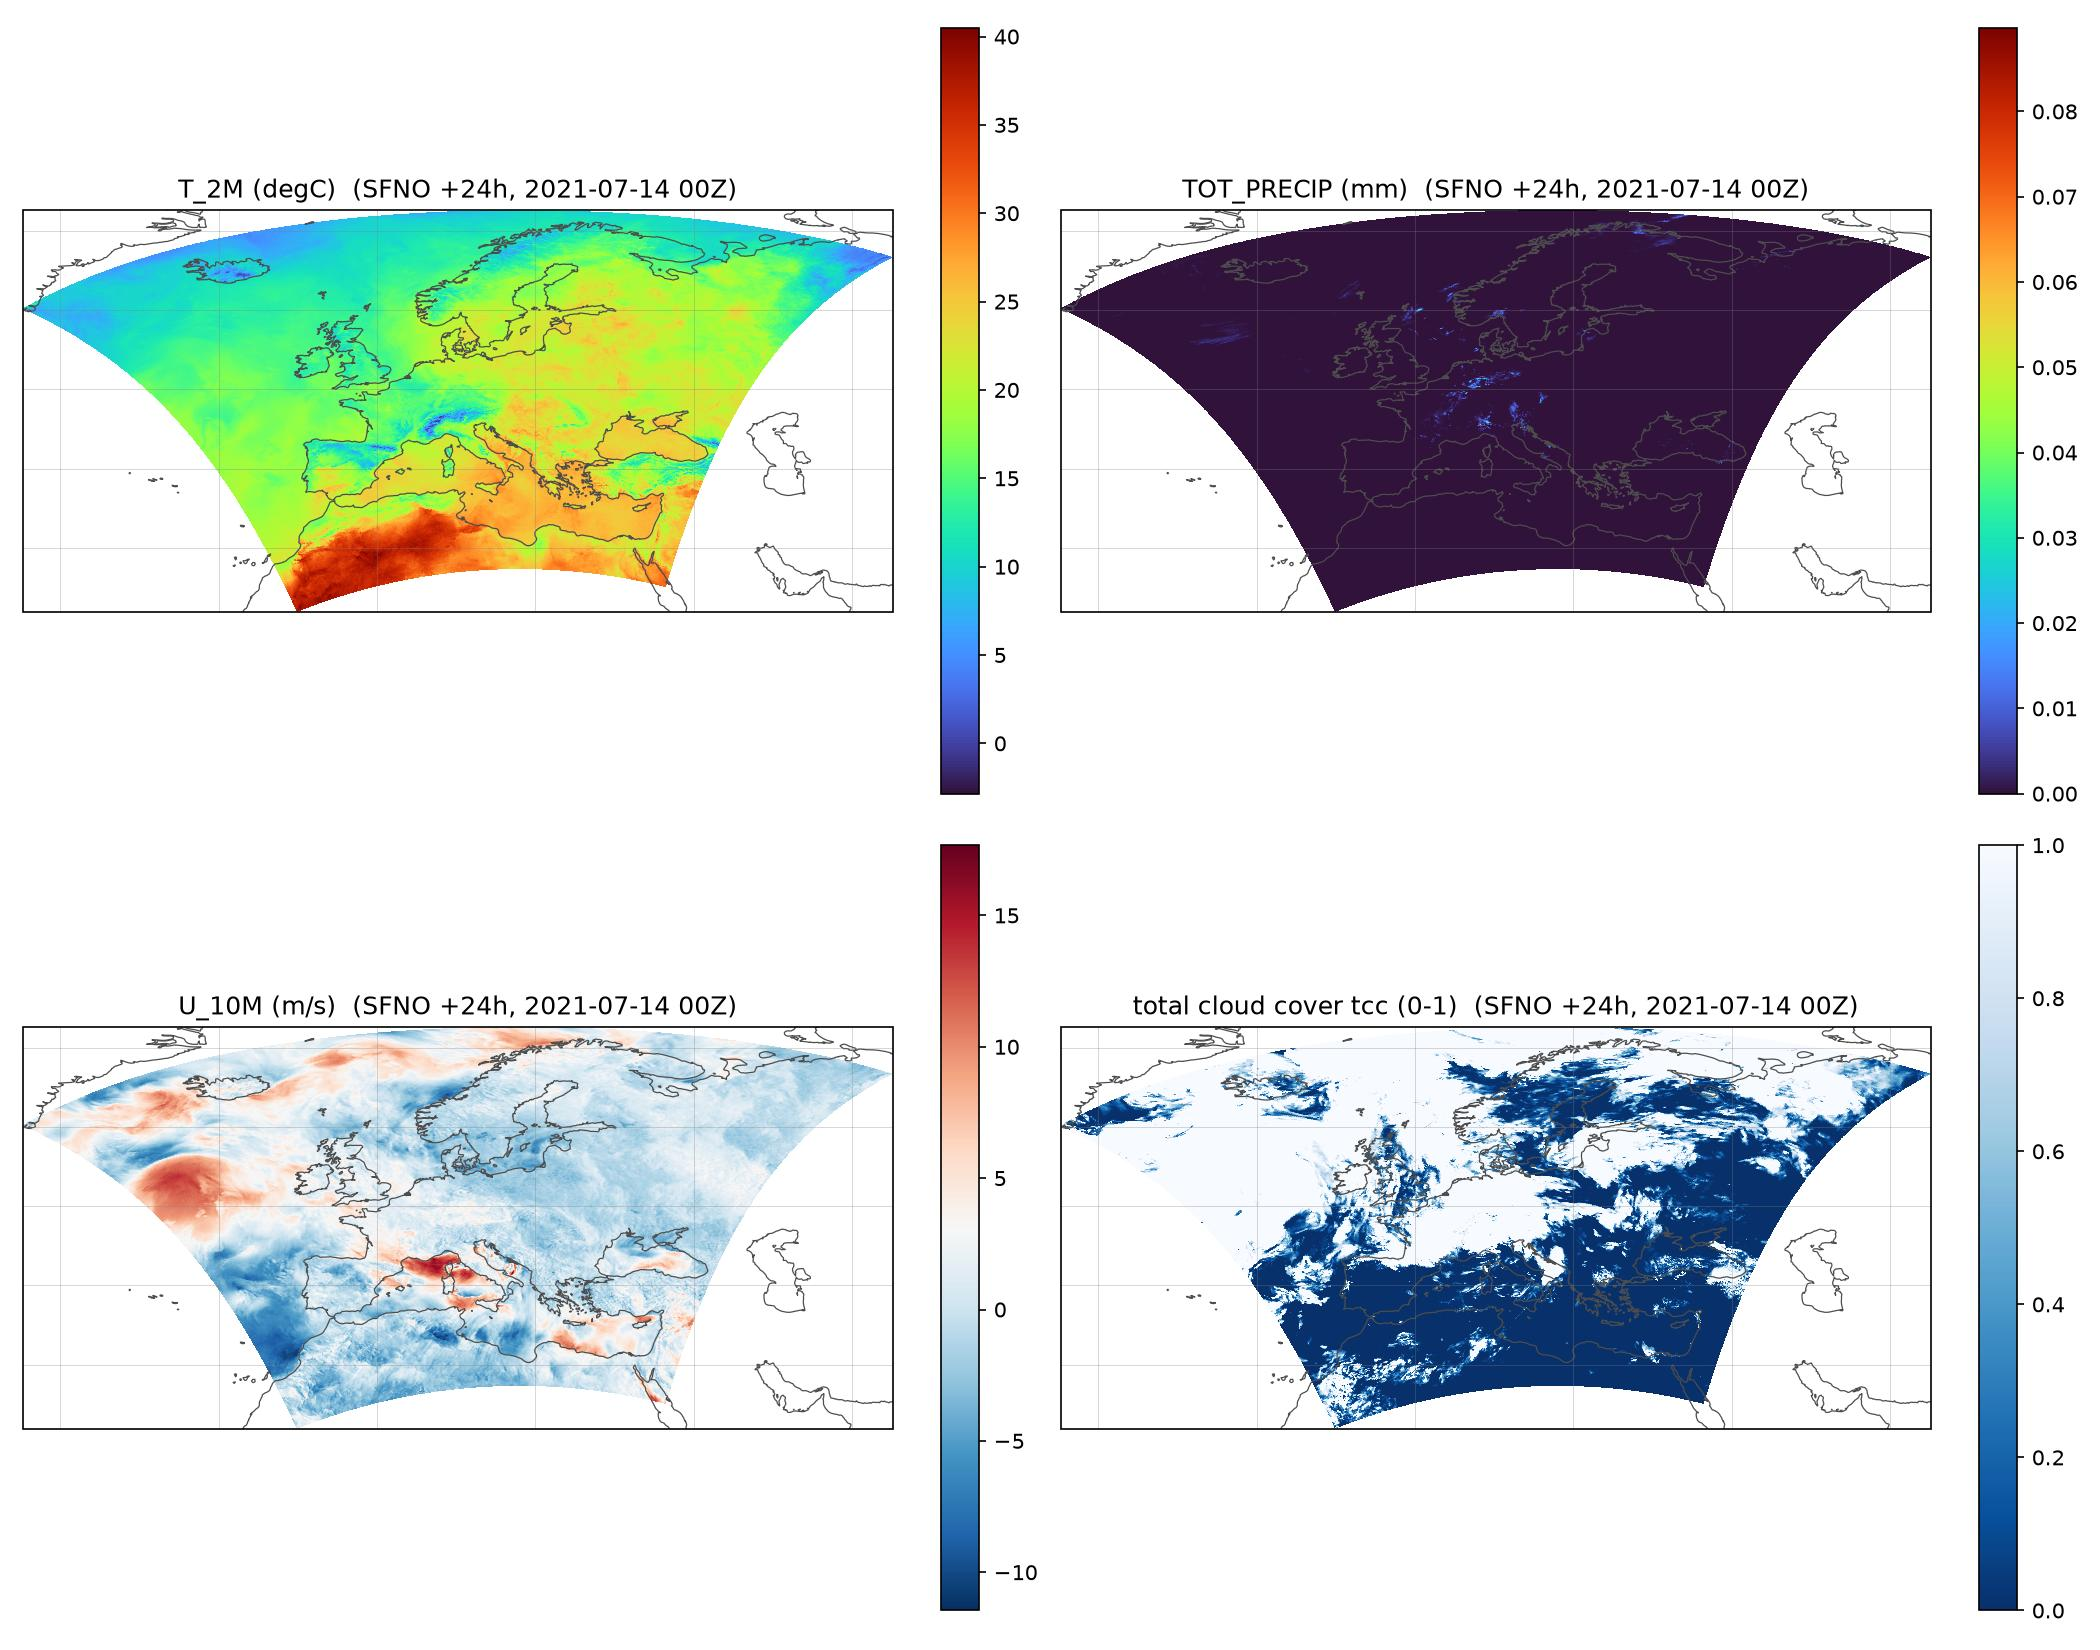

In [5]:
o = out[0, 0, 0].cpu().numpy()  # [variable, lat, lon] (batch 0, sample 0, time 0)
# ``output_variables`` are the interior COSMO names used for indexing here; the
# canonical (relabeled) names are in ``out_coords["variable"]``.
ov = dx.output_variables
lat2d, lon2d = np.asarray(out_coords["lat"]), np.asarray(out_coords["lon"])

panels = [
    ("T_2M", lambda f: f - 273.15, "T_2M (degC)", "turbo"),
    ("TOT_PRECIP", lambda f: np.clip(f, 0, None), "TOT_PRECIP (mm)", "turbo"),
    ("U_10M", lambda f: f, "U_10M (m/s)", "RdBu_r"),
    ("CLCT", lambda f: f, "total cloud cover tcc (0-1)", "Blues_r"),
]
plt.close("all")
fig, axs = plt.subplots(2, 2, figsize=(14, 11), subplot_kw={"projection": projection})
for ax, (ch, fn, label, cmap) in zip(axs.ravel(), panels):
    c = ax.pcolormesh(
        lon2d,
        lat2d,
        fn(o[ov.index(ch)]),
        transform=projection,
        shading="nearest",
        cmap=cmap,
        antialiased=False,
    )
    ax.set_title(f"{label}  (SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})")
    geo_axes(ax)
    plt.colorbar(c, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig("outputs/04_cosmo_rea_downscaling.jpg", dpi=150)


## Downscaling a smaller domain (Germany)
Often only a region of interest is needed, not the whole domain. ``set_domain``
restricts the model to a geographic bounding box: its static surface fields
(terrain, land-sea mask, ...) are sliced straight out of the full trained grid
(not interpolated), so it is valid for sub-regions inside the trained domain and
much faster -- the diffusion model processes far fewer grid patches per step. The
same SFNO forecast is reused; we just hand it to the sub-domain model.

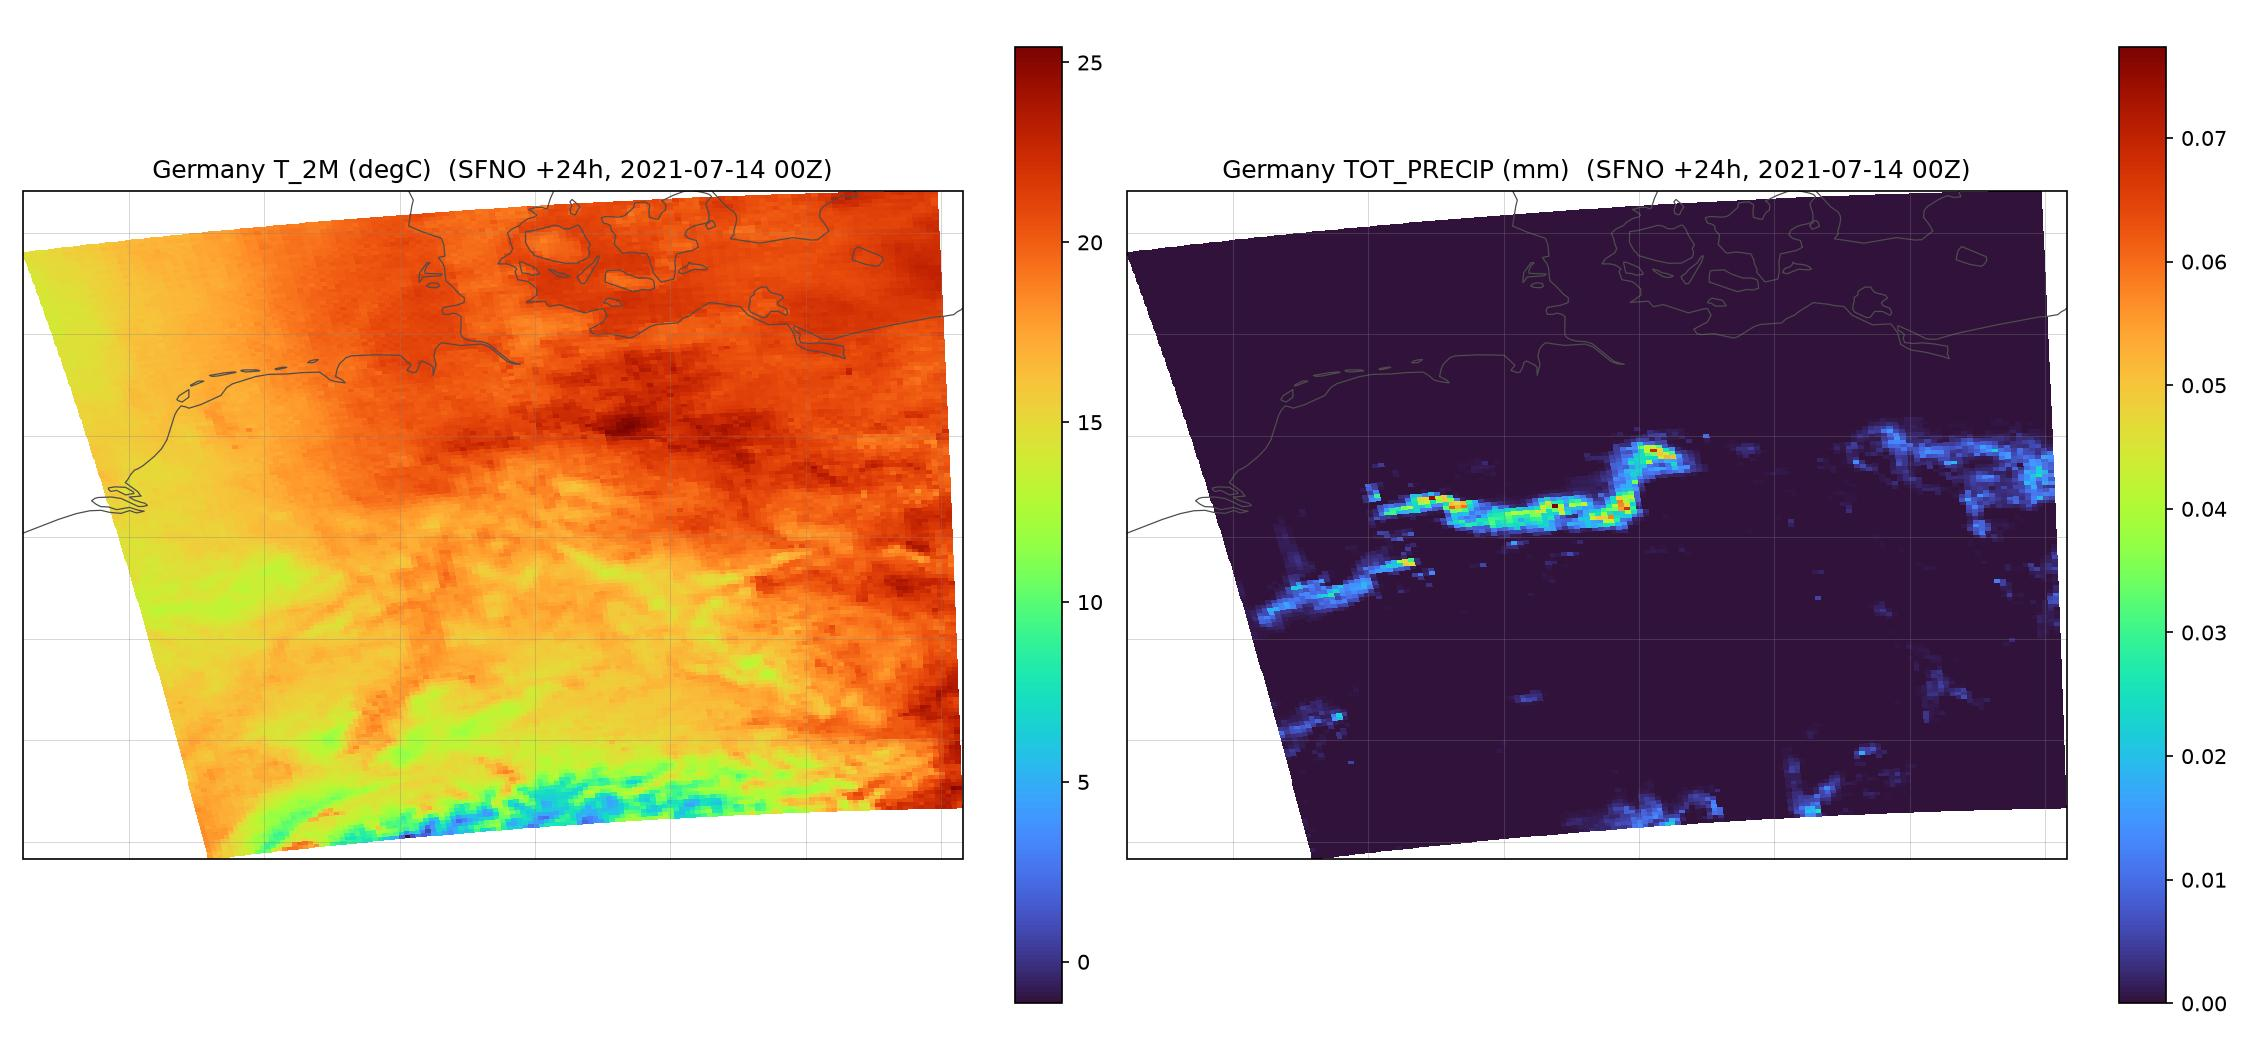

In [6]:
dx_de = dx.set_domain(**germany)
x_de, coords_de = sfno_to_downscaler(x_fc, coords_fc, dx_de, valid_time)
out_de, out_de_coords = dx_de(x_de, coords_de)

o_de = out_de[0, 0, 0].cpu().numpy()
lat_de, lon_de = np.asarray(out_de_coords["lat"]), np.asarray(out_de_coords["lon"])
plt.close("all")
fig, axs = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={"projection": projection})
for ax, (ch, fn, label, cmap) in zip(axs, panels[:2]):
    c = ax.pcolormesh(
        lon_de,
        lat_de,
        fn(o_de[ov.index(ch)]),
        transform=projection,
        shading="nearest",
        cmap=cmap,
        antialiased=False,
    )
    ax.set_title(f"Germany {label}  (SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})")
    geo_axes(ax)
    plt.colorbar(c, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("outputs/04_cosmo_rea_downscaling_germany.jpg", dpi=150)


## Framework-native chaining with ``DiagnosticWrapper``
``DiagnosticWrapper`` turns the prognostic + diagnostic into a single
prognostic, so a forecast *rollout* automatically emits the downscaled output
at every lead time. Our downscaler needs the per-step *valid* time (for the
day/night channel) and a regrid onto its regional grid, so we supply a small
callable for the wrapper's input-prep hook. We roll out over the Germany
sub-domain so each step stays fast.

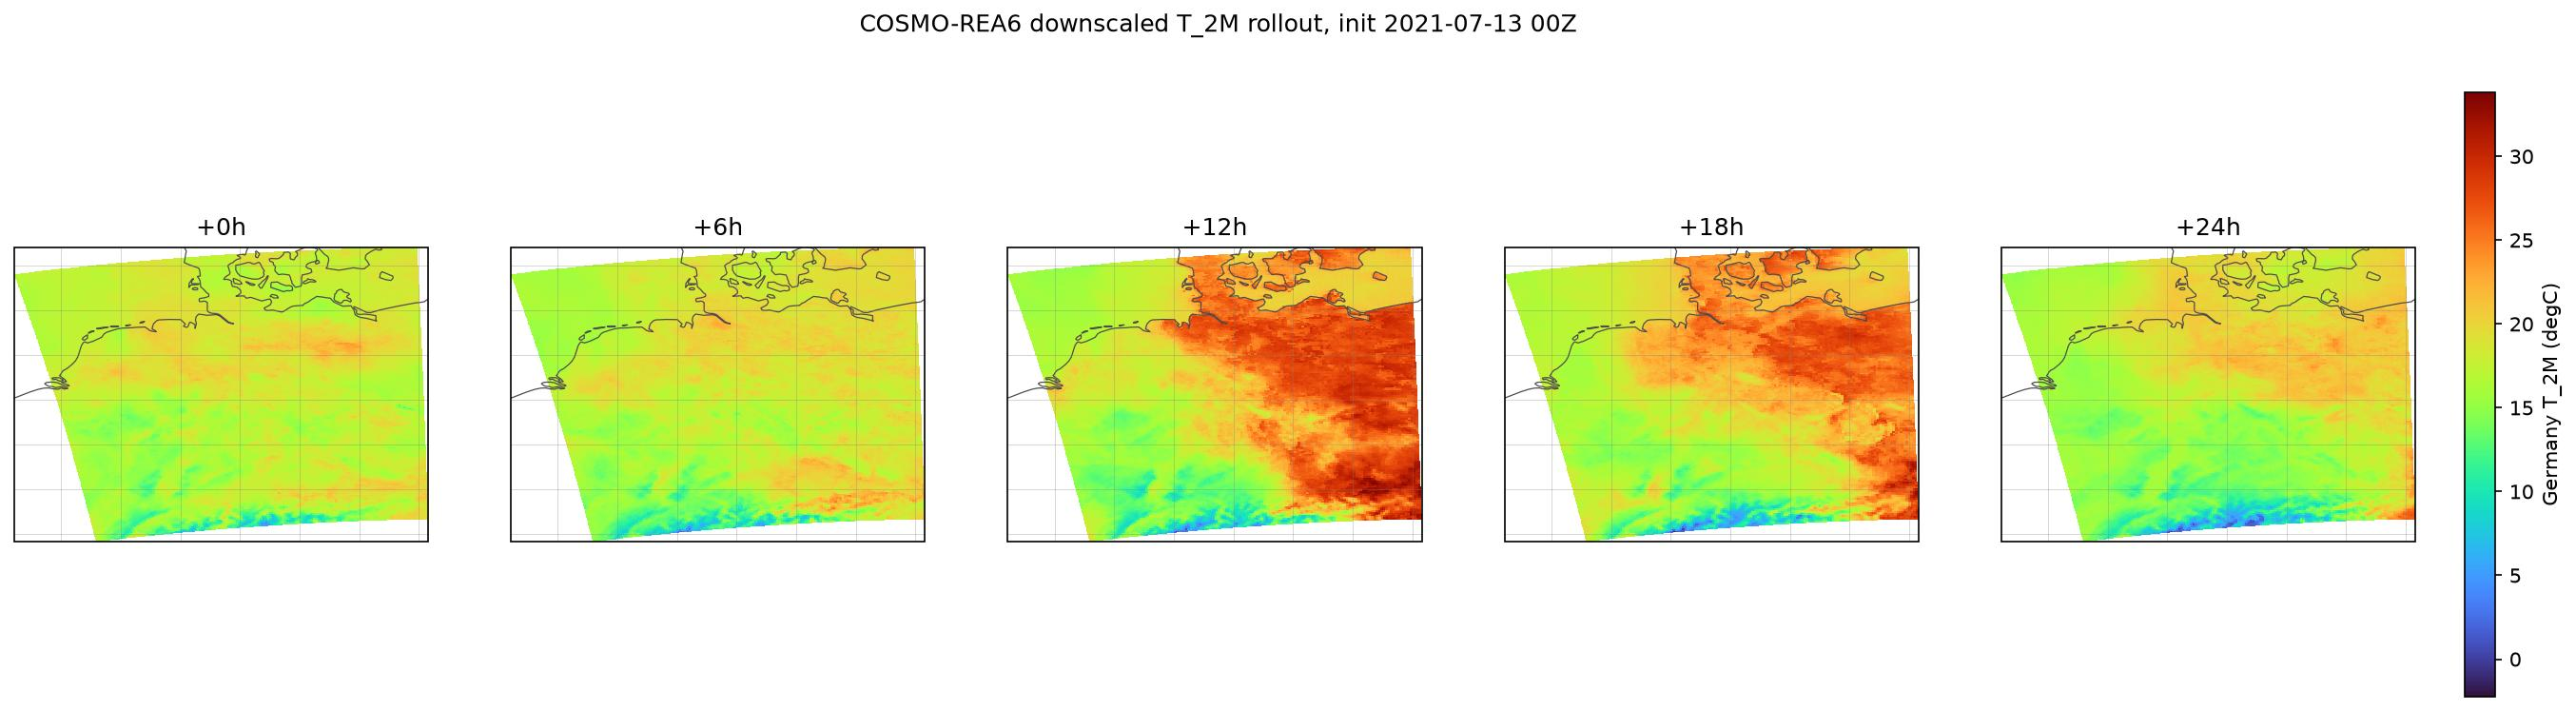

In [7]:
from earth2studio.models.px import DiagnosticWrapper


class PrepareCosmoREAInput:
    """Map a prognostic step output to the COSMO-REA downscaler input: the valid
    time (= time + lead_time) for the zenith channel, the ERA5 variable subset,
    and a lon-wrap regrid onto the downscaler's regional grid."""

    def __call__(self, x, px_coords, dx_coords):
        valid = (
            np.asarray(px_coords["time"]).reshape(-1)[0]
            + np.asarray(px_coords["lead_time"]).reshape(-1)[0]
        )
        dvars = list(dx_coords["variable"])
        dlat, dlon = np.asarray(dx_coords["lat"]), np.asarray(dx_coords["lon"])
        out = regrid_to_input(x, px_coords, dvars, dlat, dlon)
        coords = OrderedDict(
            batch=np.array([0]),
            time=np.array([np.datetime64(valid)]),
            variable=np.array(dvars),
            lat=dlat,
            lon=dlon,
        )
        return torch.from_numpy(out)[None, None].to(x.device), coords


wrapped = DiagnosticWrapper(sfno, dx_de, prepare_dx_input_tensor=PrepareCosmoREAInput())

# Roll out a downscaled Germany forecast and keep T_2M at every lead time. A real
# workflow would stream the rolled-out fields into an IO backend (e.g.
# [`earth2studio.io.ZarrBackend`][earth2studio.io.ZarrBackend]); here we keep the T_2M frames in memory to plot.
frames = {}
it = wrapped.create_iterator(x, coords)  # reuse the initial condition above
for step in range(lead_hours // dt_hours + 1):
    out_step, oc_step = next(it)
    frames[step * dt_hours] = out_step[0, 0, 0, ov.index("T_2M")].cpu().numpy() - 273.15

# Shared color scale across all lead times so the diurnal evolution is comparable.
leads = sorted(frames)
vmin = min(f.min() for f in frames.values())
vmax = max(f.max() for f in frames.values())
plt.close("all")
fig, axs = plt.subplots(
    1,
    len(leads),
    figsize=(4.5 * len(leads), 5.5),
    subplot_kw={"projection": projection},
)
for ax, lead in zip(np.atleast_1d(axs), leads):
    mesh = ax.pcolormesh(
        lon_de,
        lat_de,
        frames[lead],
        transform=projection,
        shading="nearest",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        antialiased=False,
    )
    ax.set_title(f"+{lead}h")
    geo_axes(ax)
fig.colorbar(mesh, ax=axs, fraction=0.015, pad=0.02, label="Germany T_2M (degC)")
fig.suptitle(f"COSMO-REA6 downscaled T_2M rollout, init {init_time:%Y-%m-%d %HZ}")
plt.savefig(
    "outputs/04_cosmo_rea_downscaling_rollout.jpg", dpi=150, bbox_inches="tight"
)


## Diffusion ensemble over Germany
The diffusion downscaler is generative: each sample is an independent draw from
the distribution of high-resolution fields consistent with the input forecast
state, so it expresses fine-scale uncertainty a single deterministic field
cannot. ``number_of_samples`` draws N members (independent noise per member,
seeded for reproducibility); the output's ``sample`` dim holds them. We reuse the
Germany sub-domain model and the same SFNO state, and look at total cloud cover
(CLCT), a field with strong spread. The members share one conditioning pass, so
the cost is ~N x a single sample.

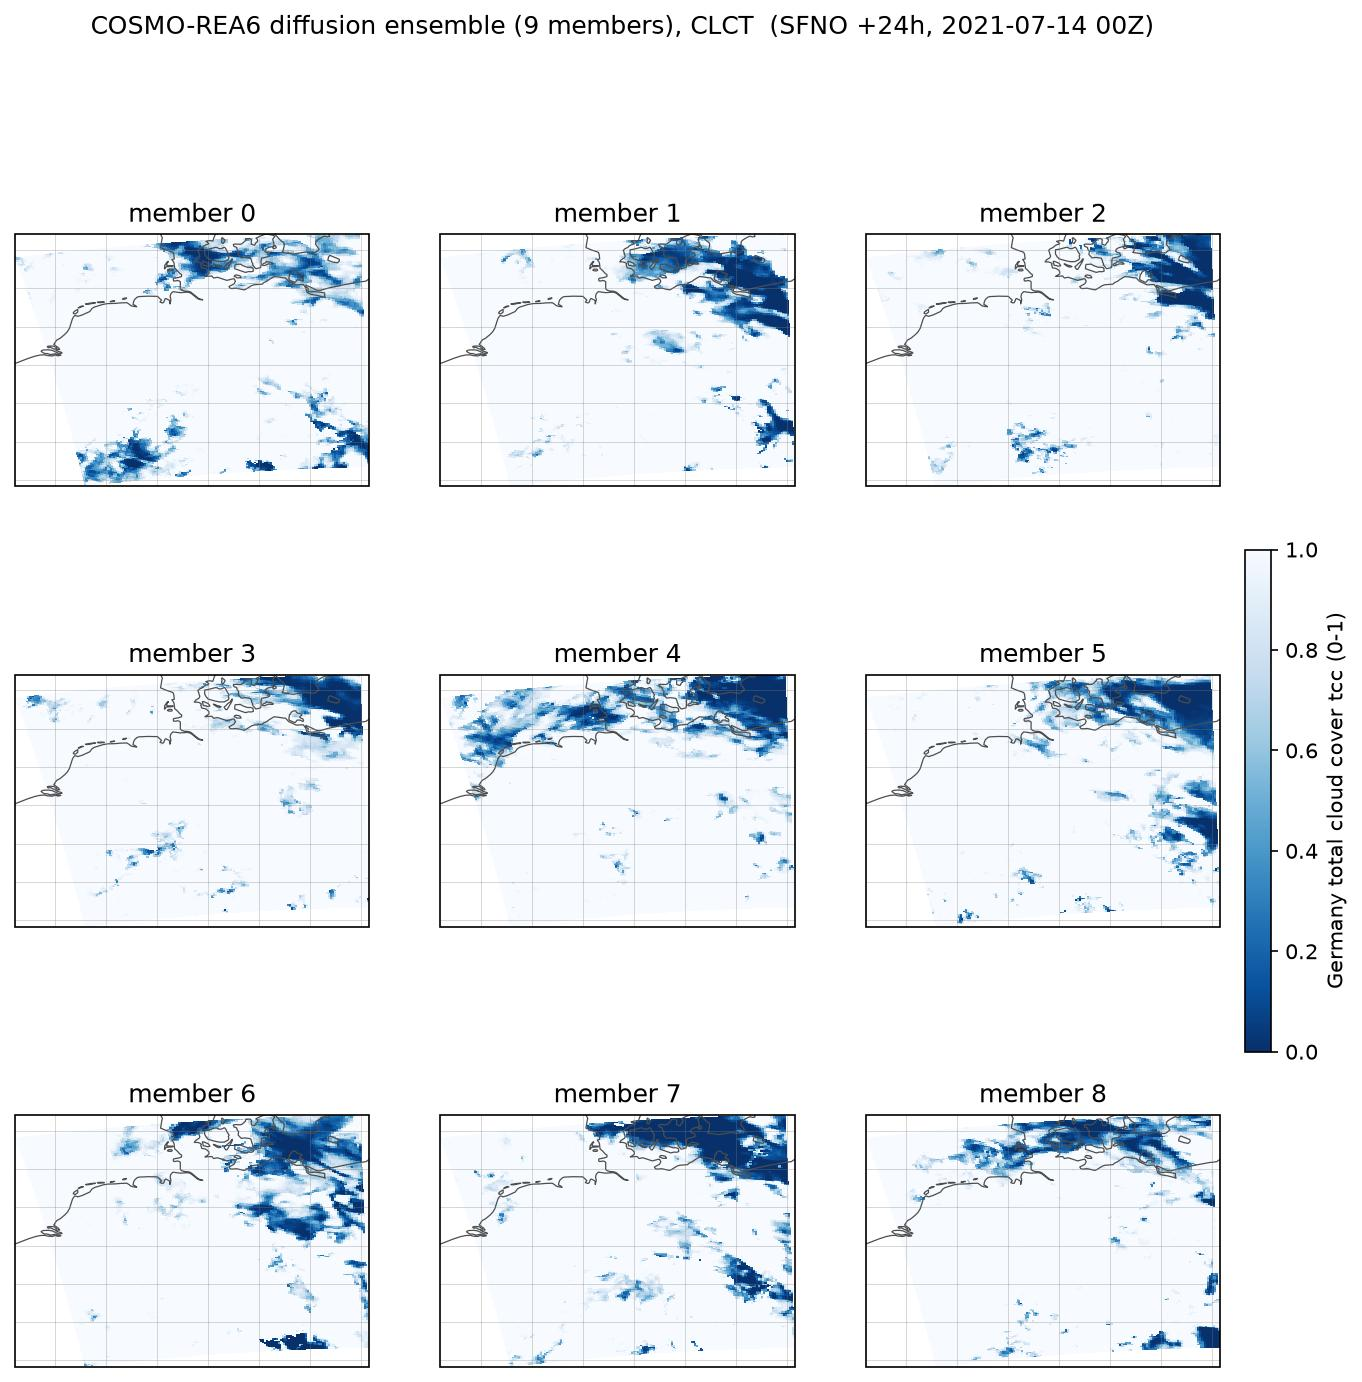

In [8]:
dx_de.number_of_samples = ensemble_size
dx_de.seed = 0  # reproducible, distinct members (seeds 0..N-1)
ens, ens_coords = dx_de(x_de, coords_de)

clct = ens[0, :, 0, ov.index("CLCT")].cpu().numpy()  # [sample, lat, lon]
ncol = int(np.ceil(np.sqrt(ensemble_size)))
nrow = int(np.ceil(ensemble_size / ncol))
plt.close("all")
fig, axs = plt.subplots(
    nrow, ncol, figsize=(3.6 * ncol, 3.6 * nrow), subplot_kw={"projection": projection}
)
for m, ax in enumerate(np.atleast_1d(axs).ravel()):
    if m >= ensemble_size:
        ax.axis("off")
        continue
    mesh = ax.pcolormesh(
        lon_de,
        lat_de,
        clct[m],
        transform=projection,
        shading="nearest",
        cmap="Blues_r",
        vmin=0,
        vmax=1,
        antialiased=False,
    )
    ax.set_title(f"member {m}")
    geo_axes(ax)
fig.colorbar(
    mesh, ax=axs, fraction=0.02, pad=0.02, label="Germany total cloud cover tcc (0-1)"
)
fig.suptitle(
    f"COSMO-REA6 diffusion ensemble ({ensemble_size} members), CLCT  "
    f"(SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})"
)
plt.savefig(
    "outputs/04_cosmo_rea_downscaling_ensemble.jpg", dpi=150, bbox_inches="tight"
)


## Regression mean vs diffusion ensemble mean (Germany)
The package also ships a deterministic *regression* (mean) model. It predicts a
single smooth field directly, whereas the diffusion *ensemble mean* is the
sample-average of the members above (an estimate of the true mean field), and the
ensemble additionally yields a spread the single regression field cannot express.
The regression has lower cell-by-cell (root-mean-square) error by construction;
the diffusion captures the full distribution and uncertainty. They are scored on
different metrics and are a tradeoff, not a ranking.

The regression is also a DiT (diffusion transformer) and crop-size agnostic at the
fixed resolution, so it runs directly on the sub-domain Germany region in a single
forward (no tiling).

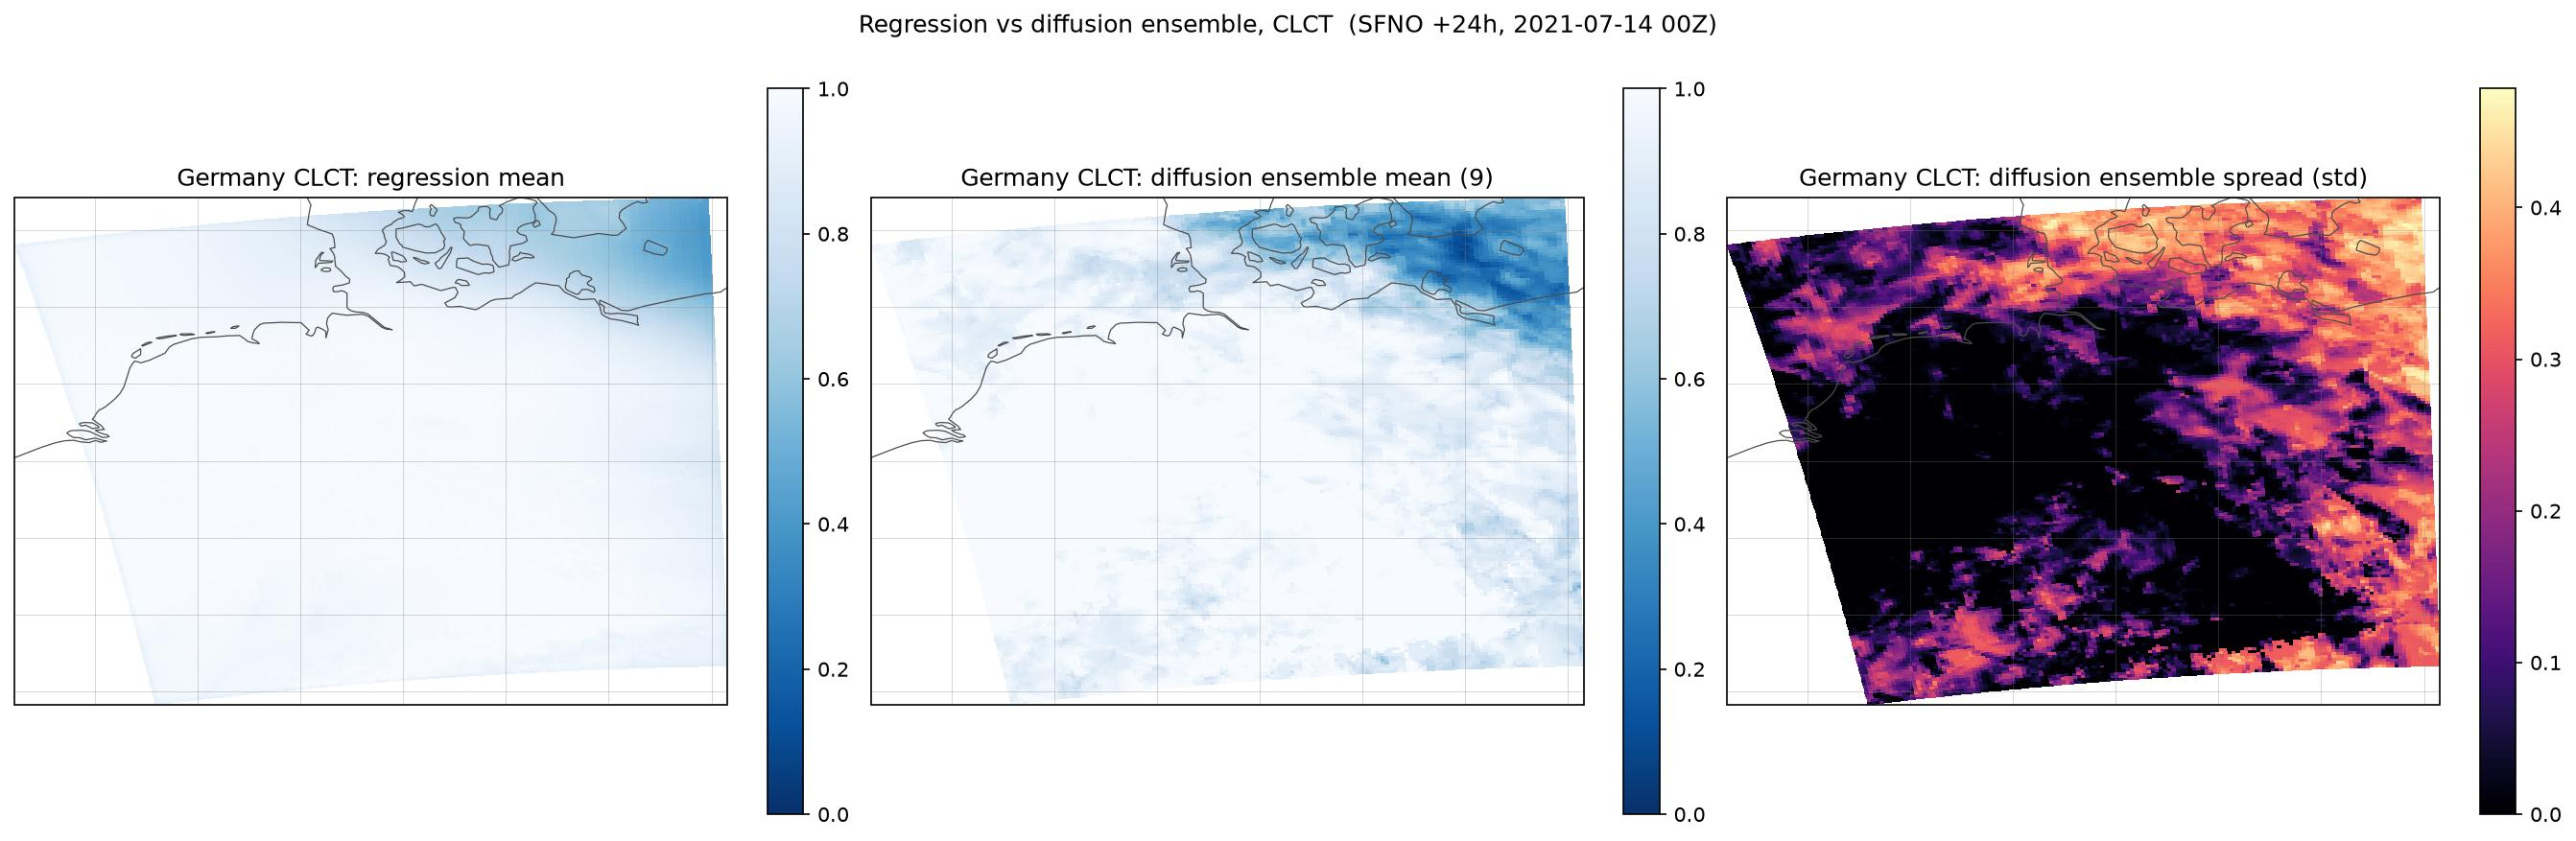

In [9]:
dx_mean_de = dx_mean.set_domain(**germany)
x_mde, coords_mde = sfno_to_downscaler(x_fc, coords_fc, dx_mean_de, valid_time)
reg_de, _ = dx_mean_de(x_mde, coords_mde)
reg_clct = reg_de[0, 0, 0, ov.index("CLCT")].cpu().numpy()

ens_mean = clct.mean(0)  # diffusion ensemble mean [lat, lon]
ens_std = clct.std(0)  # diffusion ensemble spread

comp = [
    (reg_clct, "regression mean", "Blues_r", 0.0, 1.0),
    (ens_mean, f"diffusion ensemble mean ({ensemble_size})", "Blues_r", 0.0, 1.0),
    (ens_std, "diffusion ensemble spread (std)", "magma", None, None),
]
plt.close("all")
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": projection})
for ax, (f, title, cmap, vmn, vmx) in zip(axs, comp):
    mesh = ax.pcolormesh(
        lon_de,
        lat_de,
        f,
        transform=projection,
        shading="nearest",
        cmap=cmap,
        vmin=vmn,
        vmax=vmx,
        antialiased=False,
    )
    ax.set_title(f"Germany CLCT: {title}")
    geo_axes(ax)
    plt.colorbar(mesh, ax=ax, fraction=0.046)
fig.suptitle(
    f"Regression vs diffusion ensemble, CLCT  (SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})"
)
plt.tight_layout()
plt.savefig(
    "outputs/04_cosmo_rea_downscaling_ens_vs_mean.jpg", dpi=150, bbox_inches="tight"
)


## Hub-height wind (100 m) for the energy use case
Wind-energy applications need wind at turbine hub height. Passing ``hub_heights``
to ``load_model`` appends interpolated wind COMPONENTS ``u{H}m`` / ``v{H}m``,
derived on-model by vertically interpolating the 3D wind levels (the part that
depends on the model's internal 3D grid). Wind SPEED is then a per-cell
operation: compose the stock ``DerivedWS`` wind-speed diagnostic as
``DerivedWS(levels=["100m"])``, or take the magnitude directly as below -- here,
100 m wind over Germany from the deterministic mean model.

2026-08-14 04:06:09.397 | INFO     | earth2studio.models.dx.corrdiff_cosmo_era5:load_model:1856 - Loaded CorrDiffCosmoEra5 resolution=rea6 mode=mean (45 output channels)


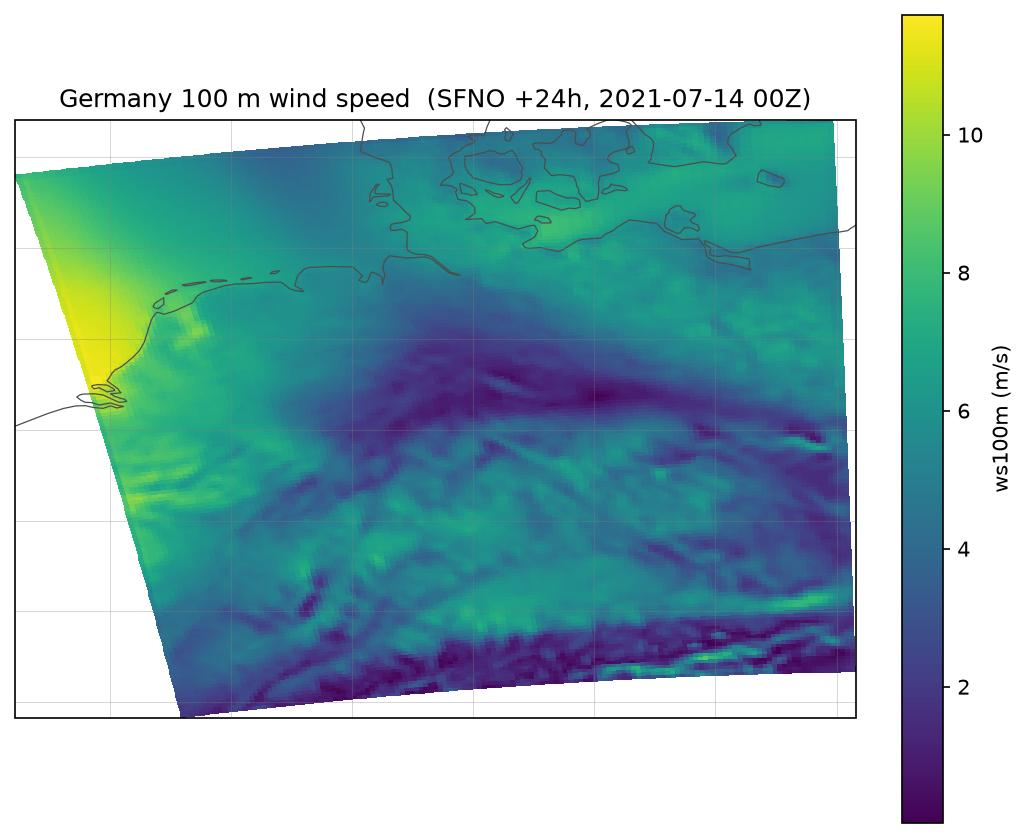

In [10]:
dx_hub = CorrDiffCosmoEra5.load_model(
    package, device=device, mode="mean", resolution="rea6", hub_heights=[100]
).set_domain(**germany)
x_hub, coords_hub = sfno_to_downscaler(x_fc, coords_fc, dx_hub, valid_time)
out_hub, hub_coords = dx_hub(x_hub, coords_hub)
hv = list(hub_coords["variable"])
u100 = out_hub[0, 0, 0, hv.index("u100m")].cpu().numpy()
v100 = out_hub[0, 0, 0, hv.index("v100m")].cpu().numpy()
ws100 = np.hypot(u100, v100)  # or compose DerivedWS(levels=["100m"]) for ws100m

plt.close("all")
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": projection})
mesh = ax.pcolormesh(
    lon_de,
    lat_de,
    ws100,
    transform=projection,
    shading="nearest",
    cmap="viridis",
    antialiased=False,
)
ax.set_title(
    f"Germany 100 m wind speed  (SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})"
)
geo_axes(ax)
plt.colorbar(mesh, ax=ax, fraction=0.046, label="ws100m (m/s)")
plt.savefig(
    "outputs/04_cosmo_rea_downscaling_hubwind.jpg", dpi=150, bbox_inches="tight"
)


## Higher resolution: COSMO-REA2 (2.2 km)
The package also ships COSMO-REA2, downscaling to a 2.2 km Central-European grid
(vs COSMO-REA6's 6 km broader-European grid). Same API, ``resolution="rea2"``.
REA2 covers a smaller domain; here we use the deterministic mean model over a
sub-region and plot 2 m temperature at 2.2 km.

2026-08-14 04:06:23.006 | INFO     | earth2studio.models.dx.corrdiff_cosmo_era5:load_model:1856 - Loaded CorrDiffCosmoEra5 resolution=rea2 mode=mean (22 output channels)


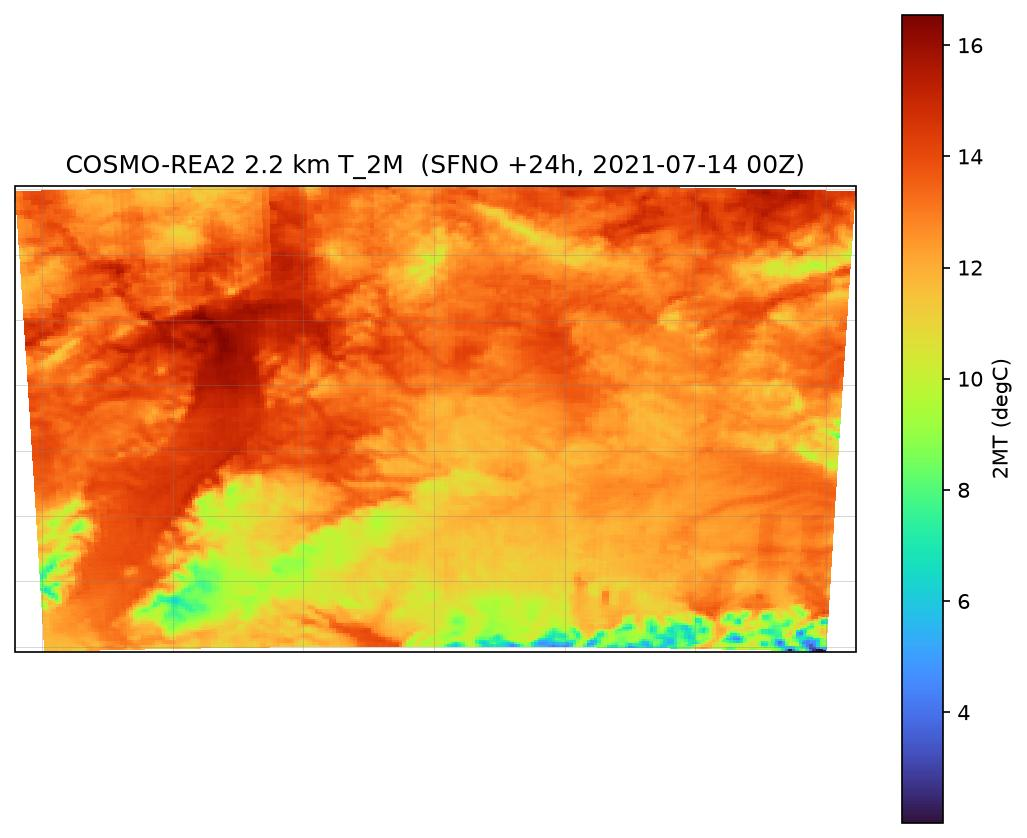

In [11]:
dx2 = CorrDiffCosmoEra5.load_model(
    package, device=device, mode="mean", resolution="rea2"
).set_domain(lat_min=47.5, lat_max=51.0, lon_min=7.0, lon_max=13.0)
x2, coords2 = sfno_to_downscaler(x_fc, coords_fc, dx2, valid_time)
out2, oc2 = dx2(x2, coords2)
o2 = out2[0, 0, 0].cpu().numpy()
# REA2's interior names differ from REA6's (2MT/10U here vs T_2M/U_10M above);
# canonical names are in oc2["variable"].
ov2 = dx2.output_variables
lat2, lon2 = np.asarray(oc2["lat"]), np.asarray(oc2["lon"])

plt.close("all")
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": projection})
mesh = ax.pcolormesh(
    lon2,
    lat2,
    o2[ov2.index("2MT")] - 273.15,
    transform=projection,
    shading="nearest",
    cmap="turbo",
    antialiased=False,
)
ax.set_title(
    f"COSMO-REA2 2.2 km T_2M  (SFNO +{lead_hours}h, {valid_time:%Y-%m-%d %HZ})"
)
geo_axes(ax)
plt.colorbar(mesh, ax=ax, fraction=0.046, label="2MT (degC)")
plt.savefig("outputs/04_cosmo_rea_downscaling_rea2.jpg", dpi=150, bbox_inches="tight")
